# Do open-neighbourhood concepts spread? Fresh-cohort test (demo)

This notebook demos **experiment 10**. It is a single-unseal confirmation of the RQ1 *openness* claim, run on a
**fresh 2015–2017 onset cohort** of OpenAlex legacy concepts that no earlier screen had touched.

**What the experiment does**
* **OPEN** is the mean of **six signed, z-scored ego-network components** of a concept's early co-occurrence
  neighbourhood: `new_edge_rate`, `n_comm_W3`, `participation`, `NOV_res`, `−ego_density_W3` and `−edge_persistence`.
  The z-score constants are **frozen** on the 12,499 EXP5 concepts. OPEN comes in three builds: ALL, HOME-ONLY and
  SIZE-MATCHED.
* The primary outcome, **O2r_m50**, is later diffusion breadth: the rarefied number of distinct fields reached at 50 papers.
* The test statistic is the **partial Spearman** (`psp`) of OPEN with O2r_m50. It controls for a ladder of covariates:
  B5 early-size and diffusion baselines, onset year, contact reach, LLM concept type and concept level (rung R2).
* **Full-run result:** the frozen verdict is CONFIRMED but marginal. OPEN_home psp at R2 is +0.091 [+0.013, +0.171]
  (n = 573). OPEN_all is +0.174, which shows that part of the signal is mechanical coupling. OPEN_home adds no practical
  prediction: the B5 Spearman is 0.768 and B5 + OPEN_home is 0.770.

**What this notebook runs**
1. `method.py`, the artifact's demo file. It is an **orchestrator** that chains the 25 pipeline steps as subprocesses:
   an OpenAlex snapshot pass, the LLM precision gate, ego-network builds, the sealed unseal and so on. These steps need
   the full OpenAlex snapshot (about 100 GB of intermediates) and paid LLM calls, so here we only *list* them.
2. The artifact's **independent re-derivation of the headline numbers** (`rederive.py`), which the orchestrator runs as
   its final step, on a curated **100-concept subset** (`mini_demo_data.json`). The code is the original code. Only the
   data loading and the iteration counts differ.
   * Rebuild OPEN_home and OPEN_all from the six raw components with the frozen constants.
   * Compute the R2 partial Spearman, with a bootstrap CI.
   * Run the within-group shuffled-outcome and random-OPEN placebos.
   * Measure the Spearman gain of the B5 + OPEN_home prediction over the B5 prediction.

> With 100 concepts instead of 573, the psp estimates are noisy. A signal of +0.09 is below what n = 100 can resolve.
> The notebook therefore prints the full-run reference values next to the demo values.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used here are pre-installed on Colab -> install locally only, at Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
The first block is `method.py`'s original import block. The second block is `rederive.py`'s. Matplotlib is added for
the final visualisation.

In [2]:
# --- method.py imports (original) ---
from __future__ import annotations

import argparse
import subprocess
import sys
from pathlib import Path

# --- rederive.py imports (original) ---
import json

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# --- added for the notebook ---
import matplotlib.pyplot as plt

## Data loading
The data is fetched from GitHub, with a fallback to a local copy of `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/main/round-4/experiment-10/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("concepts in demo subset:", len(data["examples"]))

Curated 100-concept subset (up to 16 per analysis group, evenly spread over the outcome range, topped up at random to 100) of the fresh 2015-2017 onset cohort of OpenAlex legacy concepts, with the six raw ego-network OPEN components (HOME-ONLY and ALL builds), the frozen EXP5 z-score constants, R2-ladder covariates, the primary outcome O2r_m50 and the frozen B5 / B5+OPEN_home predictions.
concepts in demo subset: 100


## Config
These are the tunable parameters of the re-derivation. The original values in `rederive.py` are 400 bootstrap draws and
200 within-group permutations, both seeded with `np.random.default_rng(1)`. On 100 concepts the full values run in
seconds, so the demo uses them unchanged.

In [5]:
N_BOOT = 400      # bootstrap draws for the psp CI            (original: 400)
N_PERM = 200      # within-group shuffled-outcome placebos     (original: 200)
SEED = 1          # rng seed                                   (original: 1)

## Step 1: the `method.py` orchestrator
This is the artifact's `method.py`, copied verbatim. There is one notebook fix: `__file__` does not exist in a notebook,
so `ROOT` points at the current directory. Each entry in `STEPS` is a stand-alone script of the pipeline:

| steps | what they do |
|---|---|
| `s0` | hash-seal the preregistration |
| `s1`, `passC*` | candidate concepts plus one zero-credit pass over the OpenAlex snapshot (2026-09-23) |
| `s3` | outcome-blind checks (T1–T3) and TAG-vs-MATCH outcome grounding |
| `s4*` | LLM precision gate (94% of candidates pass) |
| `s7_*` | ego-network builds: ALL / HOME-ONLY / SIZE-MATCHED, for EXP5 and the cohort |
| `s6`, `s5_*` | covariates, LLM concept typing and its gold-label gate |
| `s8` | indicator selection on EXP5 (the frame the constants are frozen on) |
| `s9` | the **single unseal** of the sealed outcomes and the ladder R0–R5 |
| `learned`, `audit`, `tests`, `outputs`, `report`, `rederive` | replications, independent audits and deliverables |

Running a step requires the snapshot and the LLM cache, so the demo only calls `main()` with `--list`.

In [6]:
"""Orchestrator for the fresh-cohort OPEN test. Runs the steps in order (each is also runnable on its own).

Usage: python method.py [--only STEP] [--from STEP] [--list]
Steps (in order): s0 s1 passC passC_merge s3 s4 s4_retry s7_exp5 s7_cohort s7_cohort_full s6 s5_exp5 s5_cohort
                  s5_bench s5_sheet [gold labels are read by hand -> results/type_gold_labels_v1.csv] s5_gate
                  s5_v2 s5_m2all s8 s9 learned audit tests outputs report
Note: s9 performs the SINGLE unseal; a second run only resumes scoring from the hashed outcome file."""

ROOT = Path.cwd()  # notebook fix: original was Path(__file__).resolve().parent
PY = sys.executable
STEPS = [
    ("s0", [PY, "s0_prereg.py"]),
    ("s1", [PY, "s1_candidates.py"]),
    ("passC", [PY, "passC.py", "--workers", "9"]),
    ("passC_merge", [PY, "passC.py", "--merge"]),
    ("s3", [PY, "s3_checks.py"]),
    ("s4", [PY, "s4_gate.py", "run"]),
    ("s4_retry", [PY, "s4_gate.py", "retry"]),
    ("s7_exp5", [PY, "s7_ego.py", "--frame", "exp5", "--builds", "all,home,sizematch", "--workers", "3", "--chunk", "200"]),
    ("s7_cohort", [PY, "s7_ego.py", "--frame", "cohort", "--builds", "all,home,sizematch", "--workers", "3", "--chunk", "50"]),
    ("s7_cohort_full", [PY, "s7_ego.py", "--frame", "cohort", "--builds", "full", "--workers", "5", "--chunk", "20",
                        "--tag", "_full"]),
    ("s6", [PY, "s6_covariates.py"]),
    ("s5_exp5", [PY, "s5_typing.py", "exp5"]),
    ("s5_cohort", [PY, "s5_typing.py", "cohort"]),
    ("s5_bench", [PY, "s5_typing.py", "bench"]),
    ("s5_sheet", [PY, "s5_typing.py", "sheet"]),
    ("s5_gate", [PY, "s5_typing.py", "gate"]),
    ("s5_v2", [PY, "-c", "import subprocess,sys;[subprocess.run([sys.executable,'s5_typing.py',c,'--prompt','v2'],check=True) "
                          "for c in ('exp5','cohort','bench','gate')]"]),
    ("s5_m2all", [PY, "s5_typing.py", "m2all", "--prompt", "v2"]),
    ("s8", [PY, "s8_select.py", "--nboot", "500"]),
    ("s9", [PY, "s9_unseal.py"]),
    ("learned", [PY, "-c", "import subprocess,sys;[subprocess.run([sys.executable,'s_learned.py',c],check=True) "
                           "for c in ('validate','features','score')]"]),
    ("audit", [PY, "audit.py"]),
    ("tests", [PY, "-c", "import subprocess,sys;[subprocess.run([sys.executable,t],check=True) for t in "
                         "('tests/test_output.py','tests/t_ego_flags.py','tests/t_outcomes.py','tests/test_units.py')]"]),
    ("outputs", [PY, "make_outputs.py"]),
    ("report", [PY, "make_report.py"]),
    ("rederive", [PY, "rederive.py"]),
]


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--only")
    ap.add_argument("--from", dest="start")
    ap.add_argument("--list", action="store_true")
    a = ap.parse_args()
    names = [n for n, _ in STEPS]
    if a.list:
        print("\n".join(names))
        return
    todo = STEPS
    if a.only:
        todo = [s for s in STEPS if s[0] == a.only]
    elif a.start:
        todo = STEPS[names.index(a.start):]
    for name, cmd in todo:
        print(f"== {name}: {' '.join(cmd[:4])}", flush=True)
        subprocess.run(cmd, cwd=ROOT, check=True)

In [7]:
# notebook fix: argparse reads sys.argv, which holds the kernel's arguments in Jupyter -> emulate `python method.py --list`
_argv = sys.argv
sys.argv = ["method.py", "--list"]
main()
sys.argv = _argv

s0
s1
passC
passC_merge
s3
s4
s4_retry
s7_exp5
s7_cohort
s7_cohort_full
s6
s5_exp5
s5_cohort
s5_bench
s5_sheet
s5_gate
s5_v2
s5_m2all
s8
s9
learned
audit
tests
outputs
report
rederive


## Step 2: the final pipeline step, `rederive.py`
From here on the code is the artifact's `rederive.py`. It re-derives the headline numbers *independently* of the
pipeline code path. The original reads `data/features_cohort.parquet`, `data/outcomes_cohort.parquet`,
`results/frozen_spec.json` and `data/cohort_predictions.parquet`. The demo takes the same columns and constants from
`data` instead.

`SIGN` fixes each component's direction. More new edges, more communities, higher participation and more residual
novelty count as *open*. A denser ego network and more persistent edges count as *closed*.

In [8]:
ROOT = Path.cwd()
spec = {"open_constants": data["frozen_open_constants"]}   # original: json.loads((ROOT / "results/frozen_spec.json").read_text())
F = pd.DataFrame(data["examples"])                          # original: pd.read_parquet(ROOT / "data/features_cohort.parquet")
O = F[["ci", "O2r_m50"]]                                    # original: pd.read_parquet(ROOT / "data/outcomes_cohort.parquet")[["ci", "O2r_m50"]]
D = F.drop(columns=["O2r_m50"]).merge(O, on="ci")
SIGN = {"new_edge_rate": 1, "n_comm_W3": 1, "participation": 1, "NOV_res": 1, "ego_density_W3": -1,
        "edge_persistence": -1}
print(D.shape)
D[["name", "t0", "agroup", "type", "OPEN_home", "OPEN_all", "O2r_m50"]].head(8)

(100, 33)


,name,t0,agroup,type,OPEN_home,OPEN_all,O2r_m50
0,Splenic flexure,2016,BGM+Med,object,-0.678772,-1.099164,1.000000
1,Intertriginous,2015,BGM+Med,object,-0.060034,-0.418481,1.781250
2,Sinus venosus,2015,BGM+Med,object,-0.441562,-0.592639,2.223111
3,Scleral lens,2015,BGM+Med,object,-0.786186,-1.163514,2.588661
4,Spontaneous breathing trial,2017,BGM+Med,method,-0.103842,-0.491329,2.818182
5,Pleural empyema,2016,BGM+Med,object,0.069725,0.140047,3.083333
6,Cath lab,2016,BGM+Med,object,0.548704,0.239172,3.500000
7,Glucagon receptor,2015,BGM+Med,object,-0.216651,-1.045362,3.807910


### Rebuilding OPEN from its six raw components
For each component, the value is clipped to the frozen `[lo, hi]` range and z-scored with the frozen EXP5 `mu`/`sd`.
It is then multiplied by its sign. OPEN is the mean of the six z-scores and needs at least 4 non-missing components.
The HOME-ONLY and SIZE-MATCHED builds also require ≥ 10 early papers in the concept's home field.

`design()` builds the **R2 rung** of the covariate ladder. It has these columns:
* rank-transformed B5 covariates plus CONTACT_REACH;
* onset-year dummies;
* LLM concept-type dummies, with `topic` as the reference;
* a generic flag;
* concept-level dummies.

`psp()` is the partial Spearman. It ranks x and y, residualises both on the design via QR (dropping collinear or
empty dummy columns) and correlates the residuals.

In [9]:
def open_score(build):
    c = spec["open_constants"][build]
    zs = []
    for k, s in SIGN.items():
        v = D[f"{k}__{build}"].clip(c[k]["lo"], c[k]["hi"])
        zs.append(s * (v - c[k]["mu"]) / c[k]["sd"])
    Z = pd.concat(zs, axis=1)
    o = Z.mean(axis=1, skipna=True).where(Z.notna().sum(axis=1) >= 4)
    if build != "all":
        o = o.where(D.n_home_early >= 10)
    return o


def design(d):
    cont = ["logvol", "growth_c", "offhome_share", "entropy", "reach", "CONTACT_REACH"]
    X = [np.ones(len(d))] + [d[c].rank().to_numpy() for c in cont]
    for y in (2016, 2017):
        X.append((d.t0 == y).to_numpy(float))
    for t in ("method", "object", "property"):
        X.append((d["type"] == t).to_numpy(float))
    X.append(d["generic"].to_numpy(float))
    for lv in (3, 4, 5):
        X.append((d.level == lv).to_numpy(float))
    return np.column_stack(X)


def psp(x, y, X):
    keep = np.abs(np.linalg.qr(X)[1].diagonal()) > 1e-9      # drop collinear / empty dummy columns
    Q, _ = np.linalg.qr(X[:, keep])
    rx = pd.Series(x).rank().to_numpy(); ry = pd.Series(y).rank().to_numpy()
    rx = rx - Q @ (Q.T @ rx); ry = ry - Q @ (Q.T @ ry)
    return float(np.corrcoef(rx, ry)[0, 1])

### Partial Spearman at R2, bootstrap CI and placebos
This loop runs once for the HOME-ONLY build and once for the ALL build. For each build it:
1. rebuilds OPEN and checks it against the stored frozen table, where `max_abs_diff` should be 0;
2. computes the R2 psp with O2r_m50 and a percentile bootstrap CI over concepts (`N_BOOT` draws).

For HOME it also runs two placebos. Both should look null.
* **Shuffled outcome:** O2r_m50 is permuted *within analysis group* (`N_PERM` draws). The observed |psp| is compared
  with the permutation distribution.
* **Random OPEN:** a standard-normal vector replaces OPEN.

In the full run, ALL − HOME measures *mechanical coupling*. The ALL build includes off-home neighbours, which are partly
the same papers that later count toward diffusion breadth.

In [10]:
out = {}
boot_draws = {}   # notebook addition: keep the draws for plotting
for b in ("home", "all"):
    o = open_score(b)
    out[f"OPEN_{b}_max_abs_diff_vs_frozen_table"] = float(np.nanmax(np.abs(o - F[f"OPEN_{b}"])))
    d = D.assign(o=o).dropna(subset=["o", "O2r_m50", "logvol", "growth_c", "offhome_share", "entropy", "reach"])
    d = d.reset_index(drop=True)
    est = psp(d.o.to_numpy(), d.O2r_m50.to_numpy(), design(d))
    rng = np.random.default_rng(SEED)
    bs = []
    for _ in range(N_BOOT):
        i = rng.integers(0, len(d), len(d))
        di = d.iloc[i].reset_index(drop=True)
        bs.append(psp(di.o.to_numpy(), di.O2r_m50.to_numpy(), design(di)))
    boot_draws[b] = bs
    out[f"OPEN_{b}_psp_R2"] = {"n": len(d), "est": est, "ci95_boot": [float(np.percentile(bs, 2.5)),
                                                                       float(np.percentile(bs, 97.5))]}
    if b == "home":
        # placebo 1: within-group shuffled outcome; placebo 2: random OPEN
        perm = []
        for _ in range(N_PERM):
            y = d.O2r_m50.to_numpy().copy()
            for g in d.agroup.unique():
                m = (d.agroup == g).to_numpy()
                y[m] = rng.permutation(y[m])
            perm.append(psp(d.o.to_numpy(), y, design(d)))
        perm = np.abs(perm)
        out["placebo_shuffled_outcome"] = {"q95_abs": float(np.percentile(perm, 95)),
                                           "share_ge_observed": float((perm >= abs(est)).mean())}
        rnd = psp(rng.normal(size=len(d)), d.O2r_m50.to_numpy(), design(d))
        out["placebo_random_open_psp"] = rnd

### Practical prediction: B5 vs B5 + OPEN_home
Both predictions are **frozen OLS models** fitted on the EXP5 frame and stored per concept. The first uses B5 alone and
the second uses B5 + OPEN_home. We compare their Spearman correlation with the realised O2r_m50. In the full run the
gain is +0.002, i.e. no practical improvement.

In [11]:
P = D[["ci", "pred_b5", "pred_b5_open"]].merge(O, on="ci").dropna()   # original: pd.read_parquet(ROOT / "data/cohort_predictions.parquet").merge(O, on="ci").dropna()
s0, s1 = spearmanr(P.pred_b5, P.O2r_m50)[0], spearmanr(P.pred_b5_open, P.O2r_m50)[0]
out["prediction_spearman"] = {"n": len(P), "B5": float(s0), "B5_plus_OPEN_home": float(s1), "diff": float(s1 - s0)}
# original wrote results/rederive.json; the notebook just prints it
print(json.dumps(out, indent=1))

{
 "OPEN_home_max_abs_diff_vs_frozen_table": 0.0,
 "OPEN_home_psp_R2": {
  "n": 100,
  "est": 0.19417387123372648,
  "ci95_boot": [
   -0.058985189064649245,
   0.42733744197445656
  ]
 },
 "placebo_shuffled_outcome": {
  "q95_abs": 0.23466376674979347,
  "share_ge_observed": 0.12
 },
 "placebo_random_open_psp": -0.10675824498939766,
 "OPEN_all_max_abs_diff_vs_frozen_table": 0.0,
 "OPEN_all_psp_R2": {
  "n": 100,
  "est": 0.25704521503759253,
  "ci95_boot": [
   0.027359370530844078,
   0.45737953711659707
  ]
 },
 "prediction_spearman": {
  "n": 100,
  "B5": 0.8027867710777288,
  "B5_plus_OPEN_home": 0.8087455636003793,
  "diff": 0.0059587925226505245
 }
}


## Results: demo subset vs full run
The table lists each headline quantity for the 100-concept demo subset next to the full-cohort run (`rederive.json`).
The figure has three panels:
* **(a)** the psp estimates with their bootstrap CIs;
* **(b)** the bootstrap distributions on the demo subset;
* **(c)** the frozen B5 prediction against realised diffusion breadth, coloured by OPEN_home.

        quantity  demo n  demo est      demo 95% CI  full n  full est      full 95% CI
OPEN_home psp R2     100     0.194 [-0.059, +0.427]     573     0.091 [+0.011, +0.165]
 OPEN_all psp R2     100     0.257 [+0.027, +0.457]     630     0.174 [+0.096, +0.259]

                            quantity              demo              full
OPEN rebuild max |diff| (home / all) 0.0e+00 / 0.0e+00 0.0e+00 / 0.0e+00
  shuffled-outcome placebo q95 |psp|             0.235             0.072
       share of placebos >= observed             0.120             0.015
             random-OPEN placebo psp            -0.107            -0.027
         Spearman B5 -> B5+OPEN_home    0.803 -> 0.809    0.768 -> 0.770


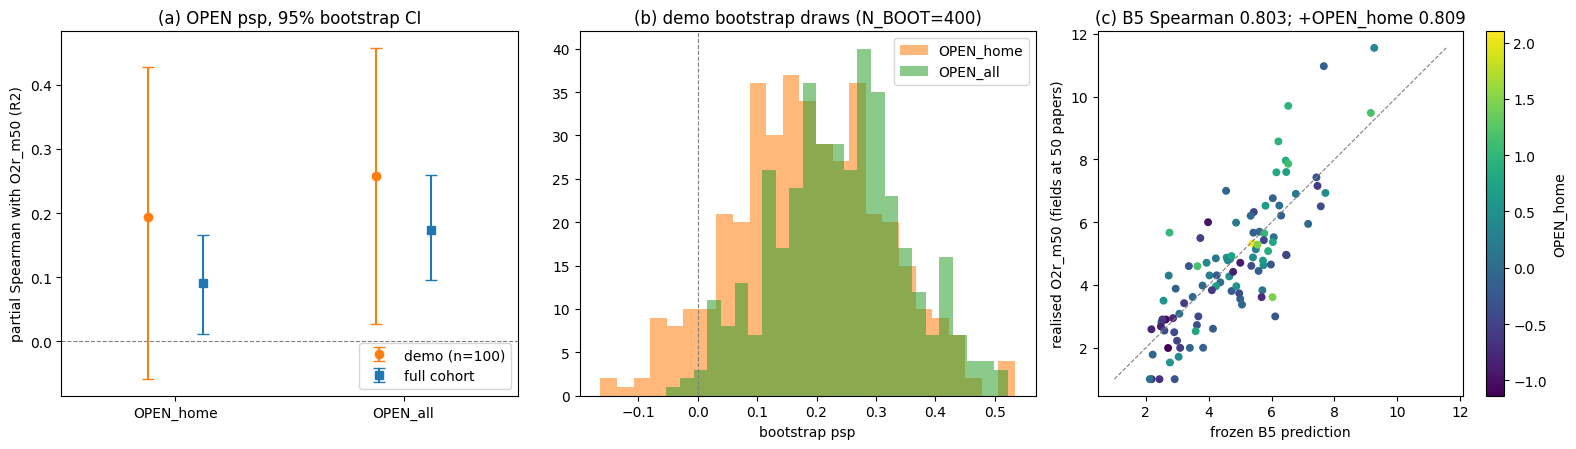

In [12]:
ref = data["reference_full_run"]
rows = [
    ("OPEN_home psp R2", out["OPEN_home_psp_R2"], ref["OPEN_home_psp_R2"]),
    ("OPEN_all psp R2", out["OPEN_all_psp_R2"], ref["OPEN_all_psp_R2"]),
]
tab = pd.DataFrame([{
    "quantity": name, "demo n": o_["n"], "demo est": round(o_["est"], 3),
    "demo 95% CI": f"[{o_['ci95_boot'][0]:+.3f}, {o_['ci95_boot'][1]:+.3f}]",
    "full n": r_["n"], "full est": round(r_["est"], 3),
    "full 95% CI": f"[{r_['ci95_400boot'][0]:+.3f}, {r_['ci95_400boot'][1]:+.3f}]"} for name, o_, r_ in rows])
extra = pd.DataFrame([
    {"quantity": "OPEN rebuild max |diff| (home / all)",
     "demo": f"{out['OPEN_home_max_abs_diff_vs_frozen_table']:.1e} / {out['OPEN_all_max_abs_diff_vs_frozen_table']:.1e}",
     "full": f"{ref['OPEN_home_max_abs_diff_vs_frozen_table']:.1e} / {ref['OPEN_all_max_abs_diff_vs_frozen_table']:.1e}"},
    {"quantity": "shuffled-outcome placebo q95 |psp|", "demo": f"{out['placebo_shuffled_outcome']['q95_abs']:.3f}",
     "full": f"{ref['placebo_shuffled_outcome']['q95_abs']:.3f}"},
    {"quantity": "share of placebos >= observed", "demo": f"{out['placebo_shuffled_outcome']['share_ge_observed']:.3f}",
     "full": f"{ref['placebo_shuffled_outcome']['share_ge_observed']:.3f}"},
    {"quantity": "random-OPEN placebo psp", "demo": f"{out['placebo_random_open_psp']:+.3f}",
     "full": f"{ref['placebo_random_open_psp']:+.3f}"},
    {"quantity": "Spearman B5 -> B5+OPEN_home",
     "demo": f"{out['prediction_spearman']['B5']:.3f} -> {out['prediction_spearman']['B5_plus_OPEN_home']:.3f}",
     "full": f"{ref['prediction_spearman']['B5']:.3f} -> {ref['prediction_spearman']['B5_plus_OPEN_home']:.3f}"},
])
pd.set_option("display.width", 200)
print(tab.to_string(index=False)); print(); print(extra.to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
# (a) point estimates + CIs, demo vs full
labels = ["OPEN_home", "OPEN_all"]
for j, (lab, (_, o_, r_)) in enumerate(zip(labels, rows)):
    ax[0].errorbar(j - 0.12, o_["est"], yerr=[[o_["est"] - o_["ci95_boot"][0]], [o_["ci95_boot"][1] - o_["est"]]],
                   fmt="o", color="tab:orange", capsize=4, label="demo (n=100)" if j == 0 else None)
    ax[0].errorbar(j + 0.12, r_["est"], yerr=[[r_["est"] - r_["ci95_400boot"][0]], [r_["ci95_400boot"][1] - r_["est"]]],
                   fmt="s", color="tab:blue", capsize=4, label="full cohort" if j == 0 else None)
ax[0].axhline(0, color="grey", lw=0.8, ls="--")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(labels); ax[0].set_xlim(-0.5, 1.5)
ax[0].set_ylabel("partial Spearman with O2r_m50 (R2)"); ax[0].set_title("(a) OPEN psp, 95% bootstrap CI"); ax[0].legend()
# (b) bootstrap distributions
for b, col in (("home", "tab:orange"), ("all", "tab:green")):
    ax[1].hist(boot_draws[b], bins=25, alpha=0.55, color=col, label=f"OPEN_{b}")
ax[1].axvline(0, color="grey", lw=0.8, ls="--")
ax[1].set_xlabel("bootstrap psp"); ax[1].set_title(f"(b) demo bootstrap draws (N_BOOT={N_BOOT})"); ax[1].legend()
# (c) frozen B5 prediction vs realised outcome
sc = ax[2].scatter(P.pred_b5, P.O2r_m50, c=D.set_index("ci").loc[P.ci, "OPEN_home"], cmap="viridis", s=22)
lim = [min(P.pred_b5.min(), P.O2r_m50.min()), max(P.pred_b5.max(), P.O2r_m50.max())]
ax[2].plot(lim, lim, color="grey", lw=0.8, ls="--")
ax[2].set_xlabel("frozen B5 prediction"); ax[2].set_ylabel("realised O2r_m50 (fields at 50 papers)")
ax[2].set_title(f"(c) B5 Spearman {out['prediction_spearman']['B5']:.3f}; +OPEN_home "
                f"{out['prediction_spearman']['B5_plus_OPEN_home']:.3f}")
plt.colorbar(sc, ax=ax[2], label="OPEN_home")
plt.tight_layout(); plt.show()

**How to read this.**
* The OPEN rebuild from raw components reproduces the frozen table exactly.
* On the full cohort, OPEN_home has a small positive partial association with later diffusion breadth, +0.091 with a CI
  just above 0. OPEN_all is about twice as large, which reflects mechanical coupling with the off-home neighbourhood.
* Neither the shuffled-outcome placebo nor the random-OPEN placebo produces a comparable signal.
* The frozen B5 baseline already predicts O2r_m50 well, and adding OPEN_home leaves the Spearman practically unchanged.
* On the 100-concept demo subset the CIs are about 2.4× wider (√(573/100)), so the demo estimates should be read as an
  illustration of the procedure, not as a replication of the verdict.